**Uploading the Datasets**

In [ ]:
# install SELFIES python package
!pip install -q selfies

In [ ]:
# import required modules
from google.colab import drive
import numpy as np
import csv
import pandas as pd
import selfies as sf
from matplotlib.ticker import PercentFormatter

In [ ]:
# mount the drive
drive.mount('/content/drive')
model2_dir = "/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Github_Upload/Model_2/"

# import the SELFIES alphabet
model2_SELFIES_alphabet = np.load(model2_dir + 'model2_SELFIES_alphabet.npy',allow_pickle='TRUE').item()

# import the SELFIES dataset
with open(model1_dir + "model2_source_task_dataset.csv", newline='') as file:
    model2_source_task_dataset = pd.read_csv(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**One-Hot Encoding of Molecular Physical Structure**

In [ ]:
# one-hot encoding
def OneHot(selfies):
    label, one_hot = sf.selfies_to_encoding(
            selfies=selfies,
            vocab_stoi=model2_SELFIES_alphabet,
            pad_to_len=76,
            enc_type = "both")
    return one_hot

for i in range (0,len(model2_source_task_dataset.index)):
  model2_source_task_dataset['ion1'][i] = OneHot(model2_source_task_dataset.iloc[i][1]) + OneHot(model2_source_task_dataset.iloc[i][2])

del model2_source_task_dataset['ion2']
model2_source_task_dataset.rename(columns = {'ion1':'ions'}, inplace = True)

<ipython-input-5-a66ba9521dce>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model2_source_task_dataset['ion1'][i] = OneHot(model2_source_task_dataset.iloc[i][1]) + OneHot(model2_source_task_dataset.iloc[i][2])


**Append Normalized Temperature as Input**

In [ ]:
# normalize temperature
# for temperature: min = 253.15, range = 219.99999999999997
for i in range(0,len(model2_source_task_dataset.index)):
  model2_source_task_dataset["temperature"][i] = (float(model2_source_task_dataset["temperature"][i]) - 253.15)/219.99999999999997

<ipython-input-8-1825496aafdf>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model2_source_task_dataset["temperature"][i] = (float(model2_source_task_dataset["temperature"][i]) - 253.15)/219.99999999999997


In [ ]:
# append temperature to one-hot encoded molecular structure
for i in range (0,len(model2_source_task_dataset.index)):
  model2_source_task_dataset['ions'][i] = np.concatenate((np.array(model2_source_task_dataset['ions'][i]).reshape(7904,), np.array([model2_source_task_dataset['temperature'][i]])))

<ipython-input-9-2a12cda9ac52>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model2_source_task_dataset['ions'][i] = np.concatenate((np.array(model2_source_task_dataset['ions'][i]).reshape(7904,), np.array([model2_source_task_dataset['temperature'][i]])))


**Training the Source Model**

In [ ]:
# upload transfer_learning.py
from google.colab import files
files.upload()

Saving transfer_learning.py to transfer_learning.py


{'transfer_learning.py': b'from __future__ import print_function, division\n\nimport torch\nimport torch.nn as nn \nimport torch.optim as optim\nfrom torch.optim import lr_scheduler\nfrom torch.autograd import Variable \n\nimport numpy as np \nimport matplotlib.pyplot as plt \nimport time \nimport os \n\nclass NeuralNet(nn.Module):\n\tdef __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):\n\t\tsuper(NeuralNet, self).__init__()\n\t\tself.fc1 = nn.Linear(input_size, hidden_size_1)\n\t\tself.fc2 = nn.Linear(hidden_size_1, hidden_size_2)\n\t\tself.fc3 = nn.Linear(hidden_size_2, output_size)\n\t\tself.relu = nn.ReLU()\n\n\tdef forward(self, x):\n\t\tout = self.fc1(x)\n\t\tout = self.relu(out)\n\t\tout = self.fc2(out)\n\t\tout = self.relu(out)\n\t\tout = self.fc3(out)\n\t\treturn out '}

In [ ]:
from transfer_learning import NeuralNet
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import os, sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
X = []
y = []
for i in range(0,len(model2_source_task_dataset.index)):
    X.append(model2_source_task_dataset['ions'][i])
    y.append(model2_source_task_dataset['density'][i]/1000)
for i in range(0,len(X)):
  X[i] = np.array(X[i]).reshape(7905,).astype(np.float32)
  y[i] = y[i].astype(np.float32)
X = np.array(X)
y = np.array(y)

In [ ]:
# preprocessing inputs: principle component analysis
PC = []
for i in range (1, 51):
  PC.append('PC'+str(i))
pca = PCA(n_components = 50)
pca.fit(X)
data_pca = pca.transform(X)
df_PCA = pd.DataFrame(data_pca,columns=PC)
X_PCA = df_PCA.to_numpy()

100%|██████████| 50000/50000 [04:57<00:00, 168.10it/s]


The MAPE on test set is 0.6118458695709705 %


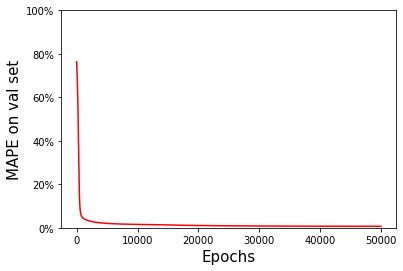

In [ ]:
# model training
input_size = 50
hidden_size_1 = 30
hidden_size_2 = 15
output_size = 1
learning_rate = 0.0001

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

X_train, X_test, y_train, y_test = train_test_split(X_PCA, y, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

scores_epochs = list()
num_epochs = 50000
train_losses = []

for epoch in tqdm(range(num_epochs)):
    inputs = torch.from_numpy(X_train)
    labels = torch.from_numpy(y_train)
    outputs = model(inputs).view(-1,)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        inputs_val = torch.from_numpy(X_val)
        labels_val = torch.from_numpy(y_val)
        outputs_val = model(inputs_val).view(-1,)
        score = mean_absolute_percentage_error(labels_val.data.numpy(), outputs_val.data.numpy())
        scores_epochs.append(score)

plt.gca().yaxis.set_major_formatter(PercentFormatter (1, decimals=0))
plt.plot(np.arange(0, num_epochs, 5), scores_epochs, color='red')
plt.ylim(0,1)
plt.xlabel('Epochs', size=15)
plt.ylabel('MAPE on val set', size=15)
print('The MAPE on test set is {}'.format(
                  mean_absolute_percentage_error(torch.from_numpy(y_test).data.numpy(), model(torch.from_numpy(X_test)).view(-1,).data.numpy())*100),'%')

# torch.save(model.state_dict(), '/content/drive/MyDrive/Colab_Notebooks/IL_Manuscript/Colab_Model_Import/density_50_PCA_model.ckpt') 